# 1.1 線形モデル（1/4）最小二乗法と正則化

**原典**: scikit-learn User Guide [1.1. Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) の 1.1.1〜1.1.6（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・線形モデルが「何を学習しているか」を説明できる<br>・最小二乗法の弱点（多重共線性）を、実験で見せられる<br>・Ridge / Lasso / Elastic-Net の違いを、1 つの図で説明できる<br>・正則化の強さ `alpha` を自動で選ぶ方法を知る |
| **前提** | Python と NumPy の基本。数式は読み飛ばしても、図と実験で理解できるように書いています |
| **目安時間** | 60〜90 分 |

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドに書かれている内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |

| 📚 **用語** | その場で初めて出てくる用語の説明 |
| 🔢 **数式を読む** | 数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** | コードを動かして、ガイドの主張を自分の目で確かめる |
| 👀 **結果の読み方** | 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |

### 目次

0. 線形モデルとは何か（導入）
1. 1.1.1 最小二乗法（OLS）
2. 1.1.2 Ridge 回帰
3. 1.1.3 Lasso
4. 1.1.4 Multi-task Lasso
5. 1.1.5 Elastic-Net / 1.1.6 Multi-task Elastic-Net
6. まとめ・確認クイズ

> 続き: [2/4 特徴選択とベイズ](./01_linear_models_2_selection_bayes.ipynb) ・ [3/4 分類と GLM](./01_linear_models_3_classification_glm.ipynb) ・ [4/4 頑健な回帰と拡張](./01_linear_models_4_robust_poly.ipynb)

## セットアップ

このノートブックは**実行済みの出力つき**で保存しています。GitHub 上で読むだけなら、実行する必要はありません。

手元で動かす場合は、`requirements.txt` の環境（scikit-learn 1.9.1）で**上から順に**実行してください。実験ごとに乱数の種を固定しているので、同じ環境なら同じ数値になります。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

---
## 0. 線形モデルとは何か

### 💡 補足: 家賃の見積もりで考える

不動産屋さんが、こんな目安で家賃を見積もっているとします。

> 家賃（万円）＝ 基本料金 2.0 ＋ 面積 × 0.2 − 駅徒歩（分）× 0.15

「面積が 1 m² 広いと +0.2 万円」「駅から 1 分遠いと −0.15 万円」という**単価**を足し合わせる考え方です。これが**線形モデル**です。

機械学習でやりたいのは、この逆です。**実際の物件データ（面積・徒歩・家賃）から、単価と基本料金を推定する**ことです。

### 📖 ガイドの解説

線形モデルは、目的変数（予測したい値）が**特徴量の線形結合**（重み付きの足し算）で表せると考える手法の集まりです。予測値 $\hat{y}$ は次の式で表されます。

$$\hat{y}(w, x) = w_0 + w_1 x_1 + \dots + w_p x_p$$

> 📚 **用語**
> - **特徴量（feature）**: 予測の手がかりにする入力の値。家賃の例では「面積」「駅徒歩」。単に**特徴**とも呼ぶ。数式では $x_1, x_2, \dots$、コードでは `X` の各列。
> - **目的変数（target）**: 予測したい値。家賃の例では「家賃」。数式では $y$、コードでは `y`。
> - **サンプル**: データの 1 件（1 物件）。`X` の 1 行に当たる。
> - **線形結合**: それぞれに係数を掛けて足し合わせたもの（$w_1 x_1 + w_2 x_2$ など）。「重み付きの足し算」。
> - **ハット記号** $\hat{y}$: 「推定値・予測値」を表す印。$y$ が本当の値、$\hat{y}$ がモデルの予測。

### 🔢 数式を読む

$$\hat{y}(w, x) = w_0 + w_1 x_1 + \dots + w_p x_p$$

| 記号 | 意味 | 家賃の例 |
|---|---|---|
| $\hat{y}(w, x)$ | 係数 $w$ と特徴 $x$ から計算した予測値 | 予測家賃 |
| $x_1, \dots, x_p$ | $p$ 個の特徴の値 | $x_1$ = 面積、$x_2$ = 徒歩 |
| $w_1, \dots, w_p$ | 各特徴の係数（1 単位増えたときの予測の増え方） | 0.2（万円 / m²）、−0.15（万円 / 分） |
| $w_0$ | 切片（すべての特徴が 0 のときの予測値） | 基本料金 2.0 |

**日本語で読むと**: 予測値は、基本料金に「各特徴 × その単価」を全部足したもの。

scikit-learn ではモジュール全体で、次の名前を使います。

| 数式 | scikit-learn の属性 | 家賃の例 |
|---|---|---|
| $w = (w_1, \dots, w_p)$ | `coef_`（係数） | 面積の単価 0.2、徒歩の単価 −0.15 |
| $w_0$ | `intercept_`（切片） | 基本料金 2.0 |

### 🧪 やってみよう: 架空の家賃データから「単価」を当てる

正解の単価を知っている架空データを作り、モデルがそれを推定できるか確かめます。

In [2]:
# 架空の物件データを 200 件作る（正解: 基本料金 2.0、面積 0.2、徒歩 -0.15）
n = 200
area = rng.uniform(15, 60, n)   # 面積 m²
walk = rng.uniform(1, 20, n)    # 駅徒歩 分
rent = 2.0 + 0.2 * area - 0.15 * walk + rng.normal(0, 0.5, n)  # 現実のばらつきとしてノイズを足す

X = np.c_[area, walk]           # 特徴量は「行 = 物件, 列 = 特徴」の 2 次元配列にする
y = rent

model = lm.LinearRegression()   # ① モデルを作る（まだ何も学習していない）
model.fit(X, y)                 # ② データから学習する

pd.DataFrame({
    "正解": [2.0, 0.2, -0.15],
    "推定値": [model.intercept_, *model.coef_],
}, index=["基本料金 (intercept_)", "面積の単価 (coef_[0])", "徒歩の単価 (coef_[1])"])

,正解,推定値
基本料金 (intercept_),2.00,1.8353
面積の単価 (coef_[0]),0.20,0.2028
徒歩の単価 (coef_[1]),-0.15,-0.1494


### 👀 結果の読み方

ノイズがあるのに、推定値は正解にかなり近くなりました。モデルはデータだけを見て、「面積が 1 m² 増えると家賃がいくら増えるか」を見つけています。

学習したモデルで、新しい物件の家賃を予測してみます。

In [3]:
new_rooms = np.array([[25, 5],    # 25 m², 徒歩 5 分
                      [40, 15]])  # 40 m², 徒歩 15 分
model.predict(new_rooms)          # ③ 予測する

array([6.1591, 7.7073])

### 🎯 なぜ線形モデルを使うのか

- **解釈しやすい**: 係数が「その特徴が 1 増えると予測がいくつ変わるか」をそのまま表すので、結果を人に説明しやすい。
- **速くて安定**: 学習も予測も軽く、データが多くても扱える。
- **ベースラインになる**: 複雑なモデルを試す前に、まず線形モデルで「どのくらい当たるか」の基準を作るのが定石。
- **拡張しやすい**: 正則化（2〜5 章）、特徴の変換（4/4 の多項式特徴）、分類（3/4 のロジスティック回帰）など、同じ骨組みでさまざまな問題に広げられる。

### 🕰️ 歴史（参考情報）

- **1805 年**: フランスの数学者**ルジャンドル**が、彗星の軌道を求める論文で**最小二乗法**を発表しました。ドイツの**ガウス**は、1795 年ごろから使っていたと主張し、1809 年に確率論的な裏付けとともに発表しています。ガウスは 1801 年、見失われた小惑星ケレスの位置をこの方法で予測し、再発見に貢献したことで知られています。
- **1880 年代**: イギリスの**フランシス・ゴルトン**が、親子の身長の研究で「子の身長は平均に近づく（回帰する）」ことを見つけ、**回帰（regression）**という言葉が生まれました。今では「数値を予測すること」全般を回帰と呼びます。

### 💡 補足: scikit-learn の基本の「型」

ここで使った 3 つの手順は、scikit-learn の**ほぼすべてのモデルで共通**です。

| 手順 | コード | 意味 |
|---|---|---|
| ① 作る | `LinearRegression()` | 設定（ハイパーパラメータ）を渡すだけ。データはまだ見ない |
| ② 学習 | `model.fit(X, y)` | データから係数などを推定して、**モデル自身に書き込む** |
| ③ 予測 | `model.predict(X_new)` | 学習した係数で新しいデータを予測する |

学習で得た値の属性名は、**末尾に `_`** が付きます（`coef_`, `intercept_`）。「`fit` した後でないと存在しない値」の目印です。

> 🧩 **プログラマ向けの見方**: TypeScript / Java にたとえると、`fit` は「自分自身を書き換えて `this` を返すメソッド」です。`new` した直後のオブジェクトは「未学習」状態で、`fit` 後に「学習済み」状態になります。型は同じまま状態だけが変わるので、`fit` 前に `coef_` を読むとエラーになります（詳しくは `../../domain-model.md`）。

この「同じ型を全モデルが守る」おかげで、後で出てくる Ridge や Lasso に**差し替えても、呼び出し側のコードは 1 行変えるだけ**で済みます。

---
## 1. 最小二乗法（1.1.1 Ordinary Least Squares）

**ねらい**: 「一番よく当てはまる直線」をどう決めているのかを知り、その弱点を実験で確かめる。

### 📖 ガイドの解説

`LinearRegression` は、**観測値と予測値の差（残差）の二乗和**が最小になるように係数 $w$ を決めます。

$$\min_{w} \| X w - y \|_2^2$$

`fit` には `X`, `y`, `sample_weight`（サンプルごとの重み）を渡せます。学習した係数は `coef_` と `intercept_` に保存されます。

> 📚 **用語**
> - **ノルム** $\|\cdot\|$: ベクトルの「長さ」。$\|v\|_2$（**L2 ノルム**）は各要素の二乗和の平方根で、普通の意味の長さ。$\|v\|_2^2$ はその二乗、つまり**各要素の二乗の合計**。
> - **$\min_w$**: 「$w$ を動かして、後ろの式を最小にする」という意味。最小にする $w$ が答え。

### 🔢 数式を読む

$$\min_{w} \| X w - y \|_2^2$$

| 記号 | 意味 |
|---|---|
| $X$ | 特徴の行列（行 = サンプル、列 = 特徴）。形は `(n_samples, n_features)` |
| $w$ | 係数のベクトル（求めたいもの） |
| $X w$ | 全サンプルの予測値を並べたベクトル（各行で「特徴 × 係数」を足したもの） |
| $y$ | 全サンプルの本当の値を並べたベクトル |
| $X w - y$ | 全サンプルの残差（予測 − 実際）を並べたベクトル |
| $\lVert \cdot\rVert _2^2$ | 各要素を二乗して足す |

**日本語で読むと**: 「全サンプルの（予測 − 実際）の二乗を合計した値」が最小になる係数を選ぶ。

### 🎯 なぜ使うのか / 🏭 利用例

- 🎯 答えが式 1 本で求まり（反復が要らない）、しかも誤差の平均が 0・互いに無相関・ばらつきが一定という条件のもとでは、「偏りのない線形の推定」の中で最もばらつきが小さい推定になることが知られています（**ガウス＝マルコフの定理**）。
- 🏭 需要予測（気温・曜日から来客数）、経済分析（価格と販売数の関係）、実験データの校正曲線、A/B テストの効果の推定など、「関係を数字で説明したい」場面の出発点として使われます。

### 💡 補足: 残差とは、なぜ「二乗」するのか

**残差**は「実際の値 − 予測値」で、下の図の赤い縦線の長さです。最小二乗法は、この赤い線の長さを**二乗して全部足した値**が最小になる直線を選びます。

- 二乗するのは、プラスとマイナスの誤差が打ち消し合わないようにするためです。
- 二乗なので、**大きく外れた点ほど強く罰する**性質があります。これは後で「外れ値に弱い」という弱点につながります（4/4 のノートで扱います）。

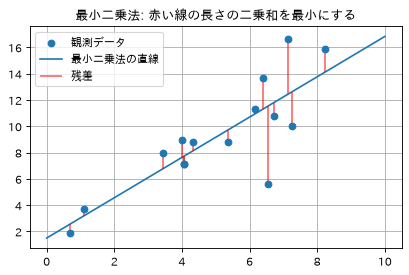

In [4]:
x1 = rng.uniform(0, 10, 15)
y1 = 1.5 * x1 + 2 + rng.normal(0, 2.5, 15)
ols = lm.LinearRegression().fit(x1[:, None], y1)   # x1[:, None] で 1 列の 2 次元配列にする

xs = np.linspace(0, 10, 2)
plt.scatter(x1, y1, zorder=3, label="観測データ")
plt.plot(xs, ols.predict(xs[:, None]), label="最小二乗法の直線")
plt.vlines(x1, y1, ols.predict(x1[:, None]), colors="red", alpha=0.6, label="残差")
plt.legend(); plt.title("最小二乗法: 赤い線の長さの二乗和を最小にする"); plt.show()

### 🧪 やってみよう: ガイドのコード例

ガイドにある最小の例を実行します。`assert` はガイドに書かれた出力と一致するかの確認です（一致しなければエラーになります）。

In [5]:
reg = lm.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
print("coef_      =", reg.coef_)
print("intercept_ =", reg.intercept_)
assert np.allclose(reg.coef_, [0.5, 0.5])   # ガイドの出力: array([0.5, 0.5])

coef_      = [0.5 0.5]
intercept_ = 1.1102230246251565e-16


### 👀 結果の読み方

このデータは、2 つの特徴がいつも同じ値（$x_1 = x_2$）です。$y = x_1$ とも $y = x_2$ とも $y = 0.5x_1 + 0.5x_2$ とも書けるので、**正解の係数が 1 つに決まりません**。`LinearRegression` はその中で係数のノルム（大きさ）が最小になる解 `[0.5, 0.5]` を返しています。

このように「特徴どうしが似すぎていて、どちらの手柄か決められない」状態が、次の多重共線性の話です。

### 📖 ガイドの解説: 多重共線性

最小二乗法の係数は、**特徴どうしが独立であること**を前提にしています。特徴どうしの相関が強く、ある列がほかの列の線形結合で近似できてしまうと、行列 $X$ が「特異（逆行列がほぼ作れない）」に近くなります。すると、目的変数のわずかなノイズで係数が大きく変わり、**推定の分散が大きく**なります。これを**多重共線性**と呼びます。実験計画なしに集めたデータで起こりがちです。

> 📚 **用語**
> - **相関**: 2 つの量が一緒に増えたり減ったりする度合い。
> - **線形従属**: ある列が、ほかの列の線形結合（重み付きの足し算）で表せてしまうこと。例: 「面積（m²）」と「面積（坪）」を両方入れると、片方はもう片方の定数倍なので線形従属。
> - **特異（singular）**: 行列が「逆行列を作れない」状態。線形従属な列があると、最小二乗法の計算に必要な行列が特異になり、係数が 1 つに決まらなくなる。「ほぼ特異」だと、計算はできても答えが極端に不安定になる。
> - **分散 / 標準偏差**: 値のばらつきの大きさ。分散は「平均からのずれの二乗」の平均、標準偏差はその平方根（元の値と同じ単位で読める）。下の実験では、同じ条件で何度も学習したときの係数のばらつきを、標準偏差で測ります。

### 💡 補足: 二人三脚のたとえ

いつも一緒に働く 2 人の社員がいて、2 人の合計成果は分かるけれど、**それぞれの貢献度は分からない**状況に似ています。「A さんが 10 割、B さんが 0 割」でも「A さんが 20 割、B さんが −10 割」でも合計は同じなので、データの少しの揺れで割り振りが大きく変わってしまいます。

### 🧪 やってみよう: 特徴が似るほど、係数はどれだけぶれるか

2 つ目の特徴を「1 つ目 + 小さなノイズ」で作り、ノイズの大きさを変えます。正解の係数は (1, 0) です。目的変数のノイズだけを変えて 200 回学習し、係数がどれだけばらつくかを測ります。

In [6]:
rng = np.random.RandomState(1)   # この実験用に乱数を固定
n = 50
x_a = rng.randn(n)
rows = []
for eps in [1.0, 0.01, 0.0001]:
    x_b = x_a + eps * rng.randn(n)     # eps が小さいほど x_a とそっくり
    X_c = np.c_[x_a, x_b]
    coefs = np.array([
        lm.LinearRegression().fit(X_c, x_a + np.random.RandomState(s).randn(n) * 0.5).coef_
        for s in range(200)
    ])
    rows.append({"x_b = x_a + ノイズ×": eps,
                 "coef_[0] の標準偏差": coefs[:, 0].std(),
                 "coef_[0] + coef_[1] の標準偏差": coefs.sum(axis=1).std()})
pd.DataFrame(rows)

,x_b = x_a + ノイズ×,coef_[0] の標準偏差,coef_[0] + coef_[1] の標準偏差
0,1.0000,0.1153,0.0764
1,0.0100,8.5095,0.0768
2,0.0001,666.6028,0.0770


### 👀 結果の読み方

- 特徴がそっくりになるほど（表の下の行ほど）、`coef_[0]` の標準偏差が**数千倍**に跳ね上がります。1 回の学習で得た係数を「この特徴の効き目」と解釈するのは危険です。
- 一方、**2 つの係数の合計**のばらつきは小さいままです。合計が安定しているので、**予測値はそれほどぶれません**。

> ⚠️ **つまずきポイント**: 多重共線性があっても予測精度はそれほど落ちないことがあります。壊れるのは「係数の解釈」です。「係数が大きいから重要な特徴だ」という読み方は、相関の強い特徴があると成り立ちません。

### 1.1.1.1 係数を非負に制限する（Non-Negative Least Squares）

📖 `positive=True` を指定すると、すべての係数が 0 以上に制限されます。頻度や商品の価格のように、物理的に負になりえない量を表す係数で役立ちます。

In [7]:
rng = np.random.RandomState(2)
X_nn = rng.randn(100, 3)
y_nn = X_nn @ [2.0, -1.0, 0.5] + 0.1 * rng.randn(100)   # 正解は [2, -1, 0.5]（2 番目が負）

pd.DataFrame({
    "正解": [2.0, -1.0, 0.5],
    "通常の OLS": lm.LinearRegression().fit(X_nn, y_nn).coef_,
    "positive=True": lm.LinearRegression(positive=True).fit(X_nn, y_nn).coef_,
}, index=["coef_[0]", "coef_[1]", "coef_[2]"])

,正解,通常の OLS,positive=True
coef_[0],2.0,1.9916,2.0826
coef_[1],-1.0,-1.0113,0.0000
coef_[2],0.5,0.4844,0.4740


👀 本当は負である `coef_[1]` が 0 に張り付きました。その分を補おうとして、**ほかの係数の値も変わっている**点に注目してください。制約は、制約をかけた係数以外にも影響します。正解の符号が本当に非負だと分かっているときだけ使いましょう。

### 1.1.1.2 計算量

📖 最小二乗解は、$X$ の**特異値分解（SVD）**で計算します。$X$ の形が `(n_samples, n_features)` のとき、計算量は $O(n_\text{samples} \cdot n_\text{features}^2)$ です（`n_samples ≥ n_features` の場合）。

> 📚 **用語**
> - **特異値分解（SVD）**: 行列を 3 つの行列の積に分解する方法。最小二乗法の答えを、特異に近い場合も含めて数値的に安定して求められる。
> - **計算量 $O(\cdot)$**: データの大きさが増えたとき、計算時間がどのように増えるかの目安。$O(n \cdot p^2)$ は「サンプル数 $n$ に比例し、特徴数 $p$ の二乗に比例する」という意味。

💡 サンプル数には比例、特徴数には**二乗**で効く、という意味です。特徴を何千個も作るときは、学習時間に注意が必要です。

---
## 2. Ridge 回帰（1.1.2 Ridge regression and classification）

**ねらい**: 「正則化」の考え方をつかみ、Ridge が多重共線性をどう抑えるかを実験で確かめる。

### 📖 ガイドの解説

Ridge 回帰は、**係数の大きさにペナルティを課す**ことで、最小二乗法の問題を和らげます。最小化する式は、残差の二乗和に「係数の二乗和 × $\alpha$」を足したものです。

$$\min_{w} \| X w - y \|_2^2 + \alpha \| w \|_2^2$$

$\alpha \ge 0$ は**縮小の強さ**を決めます。$\alpha$ が大きいほど係数は 0 に向かって縮み、共線性に対して頑健になります。

### 🔢 数式を読む

$$\min_{w} \underbrace{\| X w - y \|_2^2}_{\text{当てはまりの悪さ}} + \underbrace{\alpha \| w \|_2^2}_{\text{係数の大きさの罰}}$$

| 記号 | 意味 |
|---|---|
| $\lVert  X w - y \rVert _2^2$ | 最小二乗法と同じ、残差の二乗和 |
| $\lVert  w \rVert _2^2$ | 係数の二乗和（$w_1^2 + w_2^2 + \dots$）。係数が大きいほど大きい |
| $\alpha$ | 2 つの項のバランスを決める重み（ハイパーパラメータ）。`Ridge(alpha=...)` で指定 |

**日本語で読むと**: 「データへの当てはまり」と「係数の小ささ」の両方を考え、$\alpha$ で決めた割合で折り合いをつける。$\alpha = 0$ なら最小二乗法そのもの。

> 📚 **用語**: **縮小（shrinkage）** — 係数を 0 の方向に小さくすること。Ridge は係数を縮める推定なので、縮小推定の一種です。

### 💡 補足: 正則化 = 係数への「税金」

最小二乗法は、データに合わせるためなら係数をいくらでも大きくします。多重共線性の実験で、係数が数千倍にぶれたのはそのためです。

Ridge は係数の大きさに**税金**をかけます。$\alpha$ は税率です。

- 税率 0（$\alpha = 0$）: ただの最小二乗法
- 税率が高い: 「本当に必要な分しか係数を大きくしない」ので、極端な係数が出なくなる

このように、モデルが複雑になりすぎないよう罰則を足すことを**正則化**と呼びます。$\alpha$ のように、学習前に人が決める設定値を**ハイパーパラメータ**と呼びます。

### 🎯 なぜ使うのか

- 特徴が多い、または特徴どうしの相関が強いときに、**係数と予測を安定させる**ため。最小二乗法では係数が暴れる状況でも、少しの偏り（係数が 0 側に寄る）と引き換えに、ばらつきを大きく減らせます。
- 特徴の数がサンプル数より多くても、答えが 1 つに決まります（最小二乗法では決まらない）。

### 🏭 利用例

- **分光分析の検量線**: 近赤外線の吸収スペクトル（数百の波長 = 互いに強く相関する特徴）から、成分の濃度を予測する。
- **遺伝子データ**: 数千〜数万の遺伝子マーカーから、身長や収量などの量的な形質を予測する（ゲノミック予測）。
- **金融**: 互いに相関する多数の経済指標から、リターンを予測する。

### 🕰️ 歴史（参考情報）

- **1970 年**: 統計学者 **ホーエル（A. E. Hoerl）とケナード（R. W. Kennard）**が、論文 *Ridge regression: Biased estimation for nonorthogonal problems*（Technometrics）で提案しました。副題のとおり「わざと偏り（バイアス）のある推定をして、共線性の問題を解く」という発想で、「偏りのない推定こそ良い」という当時の常識を覆すものでした。
- 同じ考え方は、旧ソ連の数学者**ティホノフ**が、解が不安定になる問題（不良設定問題）を解くために研究した**ティホノフ正則化**としても知られています。

### 🧪 やってみよう: ガイドのコード例

In [8]:
reg = lm.Ridge(alpha=.5)
reg.fit([[0, 0], [0, 0], [1, 1]], [0, .1, 1])
print("coef_      =", reg.coef_)
print("intercept_ =", reg.intercept_)
assert np.allclose(reg.coef_, [0.34545455, 0.34545455])  # ガイドの出力と一致
assert np.isclose(reg.intercept_, 0.13636, atol=1e-5)

coef_      = [0.3455 0.3455]
intercept_ = 0.13636363636363638


### 🧪 やってみよう: 多重共線性の実験を Ridge でやり直す

OLS で係数が数千倍ぶれた、いちばん厳しい条件（`eps = 0.0001`）で、Ridge と比べます。

In [9]:
rng = np.random.RandomState(3)
x_b = x_a + 0.0001 * rng.randn(n)
X_c = np.c_[x_a, x_b]
rows = []
for name, make in [("OLS", lambda: lm.LinearRegression()),
                   ("Ridge alpha=0.1", lambda: lm.Ridge(alpha=0.1)),
                   ("Ridge alpha=1", lambda: lm.Ridge(alpha=1.0))]:
    coefs = np.array([make().fit(X_c, x_a + np.random.RandomState(s).randn(n) * 0.5).coef_
                      for s in range(200)])
    rows.append({"モデル": name, "coef_[0] の平均": coefs[:, 0].mean(),
                 "coef_[1] の平均": coefs[:, 1].mean(), "coef_[0] の標準偏差": coefs[:, 0].std()})
pd.DataFrame(rows).set_index("モデル")

,coef_[0] の平均,coef_[1] の平均,coef_[0] の標準偏差
モデル,,,
OLS,-42.8495,43.8534,803.2808
Ridge alpha=0.1,0.5015,0.5017,0.0381
Ridge alpha=1,0.4969,0.4969,0.0378


### 👀 結果の読み方

- 小さな $\alpha$ でも、係数の標準偏差が OLS の**数万分の一**に下がりました。OLS は平均すら正解から大きく外れ、2 つの係数が大きなプラスとマイナスで打ち消し合っています。
- ただし Ridge は、そっくりな 2 つの特徴に**係数を半分ずつ分け合わせます**（平均がどちらも約 0.5）。正解の (1, 0) を当てたわけではありません。そっくりな 2 つの特徴を、データだけから区別することはそもそもできないからです。
- 「どちらか 1 つを選んでほしい」ときは、後で出てくる Lasso の出番です。

### 🧪 やってみよう: $\alpha$ を変えると係数はどう縮むか（正則化パス）

$\alpha$ を小さい値から大きい値まで動かして、係数の変化を 1 枚の図にします。この図を**正則化パス**と呼びます。

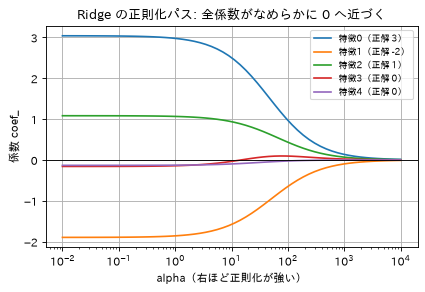

In [10]:
rng = np.random.RandomState(4)
X_r = rng.randn(60, 5)
y_r = X_r @ [3, -2, 1, 0, 0] + rng.randn(60)   # 効いているのは最初の 3 つだけ

alphas = np.logspace(-2, 4, 60)                  # 0.01 〜 10000 を対数で等間隔に
coefs = np.array([lm.Ridge(alpha=a).fit(X_r, y_r).coef_ for a in alphas])

plt.semilogx(alphas, coefs)
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("alpha（右ほど正則化が強い）"); plt.ylabel("係数 coef_")
plt.legend([f"特徴{i}（正解 {c}）" for i, c in enumerate([3, -2, 1, 0, 0])], fontsize=8)
plt.title("Ridge の正則化パス: 全係数がなめらかに 0 へ近づく"); plt.show()

👀 $\alpha$ を大きくするほど、全部の係数が**なめらかに** 0 へ近づきます。ただし、**ちょうど 0 にはなりません**。これが後で Lasso と比べるときの大事なポイントです。

### 📖 ガイドの解説: ソルバの自動選択

`Ridge` は `solver="auto"`（既定）のとき、次の条件を上から順に確かめて、最初に当てはまったソルバを使います。

| ソルバ | 条件 |
|---|---|
| `lbfgs` | `positive=True` が指定されている |
| `cholesky` | 入力 `X` が疎行列（スパース）でない |
| `sparse_cg` | 上のどれにも当てはまらない |

💡 **ソルバ**は「最小化問題を実際に解く計算方法」のことです。同じ問題を別の方法で解くので、結果はほぼ同じで速さや対応機能が違います。普段は `auto` のままで問題ありません。

### 1.1.2.2 Ridge で分類する（RidgeClassifier）

📖 Ridge には分類用の `RidgeClassifier` もあります。

- 2 クラスのとき: ラベルを **{−1, 1}** に変換して回帰問題として解き、予測値の**符号**（プラスかマイナスか）でクラスを決めます。
- 多クラスのとき: 多出力の回帰として解き、出力がいちばん大きいクラスを選びます。

分類に二乗誤差を使うのは奇妙に見えます。しかし実際には、ロジスティック回帰やヒンジ損失と同じくらいの精度になることが多く、そのうえ使える数値計算手法の選択肢が変わります。特に**クラス数が多いとき**、`LogisticRegression` よりかなり速くなることがあります。射影行列 $(X^T X)^{-1} X^T$ を 1 回計算すれば、全クラスで使い回せるからです。

### 🧪 やってみよう: 「符号で分類」を確かめる

In [11]:
rng = np.random.RandomState(5)
X_cls = np.r_[rng.randn(30, 2) + [2, 2], rng.randn(30, 2) - [2, 2]]
y_cls = np.r_[np.ones(30, int), np.zeros(30, int)]

rc = lm.RidgeClassifier().fit(X_cls, y_cls)
ridge_pm = lm.Ridge().fit(X_cls, 2 * y_cls - 1)          # 自分でラベルを {-1, 1} にして Ridge

print("predict は decision_function の符号と同じ:",
      (rc.predict(X_cls) == (rc.decision_function(X_cls) > 0)).all())
print("{-1,1} にした Ridge と係数が同じ:", np.allclose(ridge_pm.coef_, rc.coef_))
print("coef_ の形: RidgeClassifier", rc.coef_.shape,
      "/ LogisticRegression", lm.LogisticRegression().fit(X_cls, y_cls).coef_.shape)

predict は decision_function の符号と同じ: True
{-1,1} にした Ridge と係数が同じ: True
coef_ の形: RidgeClassifier (2,) / LogisticRegression (1, 2)


👀 ガイドの説明どおり、`RidgeClassifier` の中身は「ラベルを ±1 にした Ridge」そのものでした。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: 2 クラス分類で、`RidgeClassifier.coef_` の形は `(2,)`（1 次元）、`LogisticRegression.coef_` は `(1, 2)`（2 次元）です。同じ分類器でも係数の形が揃っていないので、モデルを差し替えるコードでは `np.ravel(model.coef_)` のように形を吸収する必要があります。

### 1.1.2.3 計算量

📖 最小二乗法と同じオーダーです。

### 1.1.2.4 $\alpha$ を自動で選ぶ（RidgeCV）

📖 `RidgeCV` と `RidgeClassifierCV` は、**交差検証**で $\alpha$ を自動的に選んでくれます。動きは `GridSearchCV`（3.2 節）と同じですが、既定では計算の速い **Leave-One-Out 交差検証**を使います。この既定のときは、計算式の都合で **$\alpha = 0$ を指定できません**。`cv=10` のように指定すると、`GridSearchCV` による 10 分割交差検証に切り替わります。

### 💡 補足: 交差検証（Cross-Validation）とは

「学習に使ったデータで成績を測る」と、丸暗記したモデルが高得点を取ってしまいます。そこで、データを分けて**学習に使わなかった部分で成績を測る**のが交差検証です。

- **K 分割交差検証**: データを K 個に分け、1 個をテスト用、残りを学習用にする。これを K 回繰り返して平均を取る
- **Leave-One-Out（LOO）**: K = サンプル数。1 件だけ抜いてテストすることを全件で繰り返す。普通は重いが、Ridge は数式の工夫で高速に計算できる

各 $\alpha$ の候補について成績を測り、いちばん良い $\alpha$ を選びます。詳しくは 3.1 節で学びます。

In [12]:
reg = lm.RidgeCV(alphas=np.logspace(-6, 6, 13))    # 1e-6, 1e-5, ..., 1e6 の 13 候補
reg.fit([[0, 0], [0, 0.1], [1, 1]], [0, -0.1, 1])
print("選ばれた alpha_ =", reg.alpha_)
assert np.isclose(reg.alpha_, 0.1)                   # ガイドの出力と一致

try:
    lm.RidgeCV(alphas=[0.0, 1.0]).fit(X_r, y_r)       # 既定の LOO では alpha=0 は不可
except ValueError as e:
    print("alpha=0 を含めると ValueError:", e)

選ばれた alpha_ = 0.1
alpha=0 を含めると ValueError: alphas[0] == 0.0, must be > 0.0.


---
## 3. Lasso（1.1.3）

**ねらい**: 「係数をちょうど 0 にする」正則化を理解し、Ridge との違いを図で説明できるようになる。

### 📖 ガイドの解説

Lasso は、**係数をちょうど 0 にできる**（スパースな解を作る）線形モデルです。0 でない係数が少ない解を好むので、「どの特徴を使うか」を自動で選ぶことになります。この性質から、Lasso とその仲間は圧縮センシングという分野の基礎になっています。

最小化する式は次のとおりです。Ridge との違いは、ペナルティが係数の**二乗の和**ではなく**絶対値の和**（L1 ノルム）である点です。

$$\min_{w} \frac{1}{2 n_\text{samples}} \| X w - y \|_2^2 + \alpha \| w \|_1$$

`Lasso` クラスは**座標降下法**で係数を求めます（別の解き方である LARS は 2/4 のノートで扱います）。`lasso_path` 関数を使うと、$\alpha$ を動かしたときの係数の変化（パス全体）を計算できます。

> 📚 **用語**
> - **スパース（sparse）**: 「まばら」の意味。ほとんどの要素が 0 で、0 でない要素が少ない状態。
> - **L1 ノルム** $\|w\|_1$: 各要素の**絶対値**の合計（$|w_1| + |w_2| + \dots$）。L2 ノルム（二乗和）と違い、小さな値も大きな値も「1 増えれば 1 だけ罰が増える」。
> - **圧縮センシング**: 少ない測定から、「ほとんどが 0」という性質を手がかりに元の信号を復元する技術。2/4 の OMP で体験します。

### 🔢 数式を読む

$$\min_{w} \underbrace{\frac{1}{2 n_\text{samples}} \| X w - y \|_2^2}_{\text{当てはまりの悪さ（平均）}} + \underbrace{\alpha \| w \|_1}_{\text{係数の絶対値の罰}}$$

| 記号 | 意味 |
|---|---|
| $\frac{1}{2 n_\text{samples}}$ | 残差の二乗和をサンプル数で割って「平均」にする係数（$\frac{1}{2}$ は微分したときに式をきれいにするため）。これにより、`alpha` の効き方がサンプル数にあまり左右されない |
| $\lVert  w \rVert _1$ | 係数の絶対値の合計 |
| $\alpha$ | 罰の強さ。大きいほど 0 になる係数が増える |

**日本語で読むと**: 「平均的な当てはまりの悪さ」と「係数の絶対値の合計」の両方を小さくする。絶対値の罰は、係数を少しでも 0 から離すと必ずかかるので、効き目の小さい係数は 0 にしたほうが得になる。

> ⚠️ **つまずきポイント**: Ridge の式には $\frac{1}{2 n_\text{samples}}$ がなく、Lasso の式にはあります。そのため、同じ `alpha=1.0` でも、Ridge と Lasso では正則化の強さの意味がまったく違います。値をそのまま使い回さないようにしましょう。

### 🎯 なぜ使うのか

- **予測と特徴選択を同時に**行えるため。どの特徴が効いているかを、モデル自身が 0 / 非 0 で教えてくれます。
- 特徴が非常に多く、そのうち本当に効くのは一部だけ、と考えられるときに強い。

### 🏭 利用例

- **遺伝子研究**: 数万の遺伝子の中から、病気に関係する少数の遺伝子を見つける。
- **医用画像**: MRI の撮影時間を短くするため、少ない測定から画像を復元する（圧縮センシング。ガイドの例「Compressive sensing: tomography reconstruction with L1 prior」もこの応用）。
- **説明しやすいモデルづくり**: 「このスコアは 5 つの指標だけで計算しています」と言える、単純なモデルを作る。

### 🕰️ 歴史（参考情報）

- **1996 年**: 統計学者 **ロバート・ティブシラニ**が、論文 *Regression Shrinkage and Selection via the Lasso*（ガイドの参考文献）で提案しました。Lasso は **Least Absolute Shrinkage and Selection Operator**（最小絶対値による縮小と選択の演算子）の頭文字です。英語の lasso（投げ縄）にもかけた名前です。
- 2000 年代半ばに、ドノホー、カンデス、タオらによって**圧縮センシング**の理論が整えられ、「L1 ノルムで疎な解を探す」考え方は信号処理でも中心的な道具になりました。

### 💡 補足: Ridge は「一律減給」、Lasso は「不要な人を外す」

同じ「税金」でも、かけ方が違います。

- **Ridge（二乗のペナルティ）**: 大きい係数ほど重く罰し、小さい係数はほとんど罰しない。だから全員を少しずつ縮めるが、誰も 0 にはならない（一律減給）
- **Lasso（絶対値のペナルティ）**: 係数の大きさに関係なく、1 増やすごとに同じ額の罰。小さな効き目しかない特徴は「コストに見合わない」ので、**ちょうど 0** にされる（不要な人を外す）

### 🧪 やってみよう: ガイドのコード例

In [13]:
reg = lm.Lasso(alpha=0.1)
reg.fit([[0, 0], [1, 1]], [0, 1])
print("predict([[1, 1]]) =", reg.predict([[1, 1]]))
assert np.allclose(reg.predict([[1, 1]]), [0.8])     # ガイドの出力と一致
print("coef_ =", reg.coef_)

predict([[1, 1]]) = [0.8]
coef_ = [0.6 0. ]


👀 係数を見ると、そっくりな 2 つの特徴のうち**片方だけ**に係数が付き、もう片方は 0 になっています。Ridge が半分ずつ分け合ったのとは対照的です。

### 🧪 やってみよう: 10 個の特徴のうち、本当に効くのが 2 個だけのとき

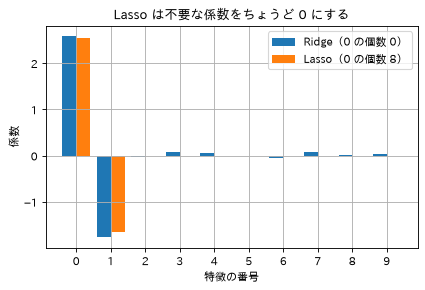

In [14]:
rng = np.random.RandomState(6)
X_s = rng.randn(100, 10)
y_s = 3 * X_s[:, 0] - 2 * X_s[:, 1] + 0.5 * rng.randn(100)   # 効くのは特徴 0 と 1 だけ

ridge_c = lm.Ridge(alpha=10).fit(X_s, y_s).coef_
lasso_c = lm.Lasso(alpha=0.3).fit(X_s, y_s).coef_

idx = np.arange(10)
plt.bar(idx - 0.2, ridge_c, width=0.4, label=f"Ridge（0 の個数 {(ridge_c == 0).sum()}）")
plt.bar(idx + 0.2, lasso_c, width=0.4, label=f"Lasso（0 の個数 {(lasso_c == 0).sum()}）")
plt.xticks(idx); plt.xlabel("特徴の番号"); plt.ylabel("係数")
plt.legend(); plt.title("Lasso は不要な係数をちょうど 0 にする"); plt.show()

👀 Ridge は、効かない 8 個の特徴にも小さな係数を残しています。Lasso は 8 個を**ぴったり 0** にしました。その代わり、効いている係数（特徴 1 の −2 など）も少し小さく見積もっています。「0 にする力」と「縮める力」は同じ罰則から来ているので、切り離せません。

### 🧪 やってみよう: Lasso の正則化パス

Ridge と同じ図を Lasso で描きます。

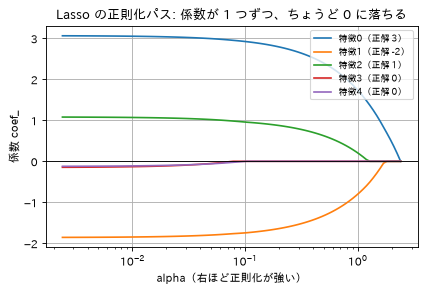

In [15]:
lasso_alphas, lasso_coefs, _ = lm.lasso_path(X_r, y_r)
plt.semilogx(lasso_alphas, lasso_coefs.T)
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("alpha（右ほど正則化が強い）"); plt.ylabel("係数 coef_")
plt.legend([f"特徴{i}（正解 {c}）" for i, c in enumerate([3, -2, 1, 0, 0])], fontsize=8)
plt.title("Lasso の正則化パス: 係数が 1 つずつ、ちょうど 0 に落ちる"); plt.show()

👀 Ridge の図と見比べてください。Lasso では、$\alpha$ を大きくすると係数が**ある点でぴたりと 0 になり**、その後は 0 のままです。効き目の小さい特徴から順に外れていきます。

> 📖 **ガイドのノート**: Lasso はスパースなモデルを作るので、**特徴選択**に使えます（1.13 節「L1-based feature selection」）。

### 1.1.3.1 座標降下法と Gap Safe Screening

📖 **座標降下法**は、係数を **1 つずつ**順番に最適化していく方法です。ほかの係数を固定すれば、1 つの係数 $w_j$ についての 1 次元の問題になり、簡単に解けます。その解は**ソフトしきい値関数** $S$ で書けます。

$$w_j = \frac{S\left(x_j^T (y - X_{-j} w_{-j}),\ \alpha\right)}{\| x_j \|_2^2}, \qquad S(z, \alpha) = \operatorname{sign}(z) \max(0, |z| - \alpha)$$

$S$ は、$|z| \le \alpha$ のとき**ちょうど 0** になります。特徴を順番に（`selection="cyclic"`）またはランダムに（`selection="random"`）選んで更新を繰り返し、**双対ギャップ**（今の解が最適解からどれだけ離れているかの上限）が `tol` より小さくなったら止めます。

> 📚 **用語**
> - **座標降下法（coordinate descent）**: たくさんの変数を一度に動かす代わりに、1 つずつ順番に「その変数だけで見た最適値」に更新していく方法。山の地図で、東西方向だけ、南北方向だけと交互に動いて谷底を探すイメージ。
> - **ソフトしきい値関数** $S(z, \alpha)$: 値 $z$ を 0 の方向に $\alpha$ だけ近づけ、0 を越えそうなら 0 で止める関数。
> - **$X_{-j}$, $w_{-j}$**: 「$j$ 番目の特徴を除いた残り全部」。$y - X_{-j} w_{-j}$ は、$j$ 番目以外の特徴で説明しきれなかった部分（部分残差）。
> - **双対ギャップ（duality gap）**: 最適化の理論で、「今の解の目的関数の値」と「最適値の下限」の差。0 なら最適解に到達している。計算をいつ止めるかの目安に使う。

### 🔢 数式を読む: 座標降下法の 1 ステップ

$$w_j = \frac{S\left(x_j^T (y - X_{-j} w_{-j}),\ \alpha\right)}{\| x_j \|_2^2}$$

1. $y - X_{-j} w_{-j}$: $j$ 番目以外の特徴で説明した残り（部分残差）
2. $x_j^T (\cdots)$: その残りと、$j$ 番目の特徴がどれだけ同じ向きか（内積）。大きいほど $x_j$ で説明できる部分が大きい
3. $S(\cdots, \alpha)$: それが $\alpha$ 以下なら 0（この特徴は使わない）、超えていれば $\alpha$ だけ差し引く
4. $/ \| x_j \|_2^2$: 特徴の大きさ（スケール）で割って、係数の単位に直す

**日本語で読むと**: 「ほかの特徴で説明しきれなかった部分を、$j$ 番目の特徴がどれだけ説明できるか」を測り、それが罰 $\alpha$ に見合わなければ 0 にする。

**Gap Safe Screening** は、最適解で 0 になると**確実に分かる**特徴を、計算の途中で安全に取り除いて高速化する工夫です。

### 💡 補足: なぜ Lasso は 0 を作れるのか（1 枚の図で）

特徴どうしが直交している単純なケースでは、Ridge と Lasso の解は「正則化なしの係数 $z$」を次のように変換したものになります。

- Ridge: $z$ を**一定の割合で縮める**（$z / (1 + \alpha')$）
- Lasso: $z$ を**一定の量だけ 0 に近づけ、0 を越えたら 0 で止める**（ソフトしきい値）

グラフにすると違いは一目瞭然です。

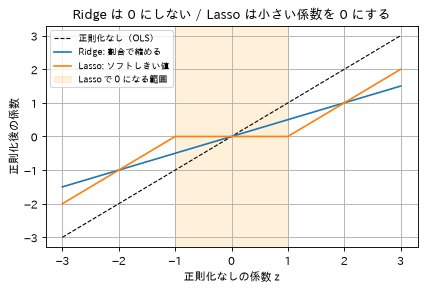

In [16]:
z = np.linspace(-3, 3, 301)
a = 1.0
plt.plot(z, z, "k--", lw=1, label="正則化なし（OLS）")
plt.plot(z, z / (1 + a), label="Ridge: 割合で縮める")
plt.plot(z, np.sign(z) * np.maximum(0, np.abs(z) - a), label="Lasso: ソフトしきい値")
plt.axvspan(-a, a, color="orange", alpha=0.15, label="Lasso で 0 になる範囲")
plt.xlabel("正則化なしの係数 z"); plt.ylabel("正則化後の係数")
plt.legend(fontsize=8); plt.title("Ridge は 0 にしない / Lasso は小さい係数を 0 にする"); plt.show()

👀 Ridge の線は原点以外で 0 になりません。Lasso の線は、オレンジの範囲（$|z| \le \alpha$）で**水平に 0** です。「効き目が $\alpha$ 以下の特徴は外す」という動作が、式の形そのものに組み込まれています。

### 🧪 やってみよう: ソフトしきい値の式を、実際の `Lasso` と照合する

列が直交していて $\|x_j\|^2 = n$ のデータなら、$w_j = S(x_j^T y / n,\ \alpha)$ が厳密に成り立つはずです。

In [17]:
rng = np.random.RandomState(7)
n_o = 200
X_o = np.linalg.qr(rng.randn(n_o, 4))[0] * np.sqrt(n_o)   # 列どうしが直交、各列の二乗和 = n
y_o = X_o @ [3, 1, 0.2, -0.05] + 0.01 * rng.randn(n_o)
alpha = 0.3

z_o = X_o.T @ y_o / n_o
manual = np.sign(z_o) * np.maximum(0, np.abs(z_o) - alpha)
sk = lm.Lasso(alpha=alpha, fit_intercept=False, tol=1e-12).fit(X_o, y_o).coef_

print("手計算（ソフトしきい値）:", manual)
print("sklearn の Lasso       :", sk)
assert np.allclose(manual, sk, atol=1e-4)

手計算（ソフトしきい値）: [ 2.7008  0.6999  0.     -0.    ]
sklearn の Lasso       : [ 2.7008  0.6999  0.     -0.    ]


👀 一致しました。正解の係数 0.2 と −0.05 は $\alpha = 0.3$ より小さいので、ちょうど 0 になっています。

> ⚠️ **つまずきポイント**: 上のコードで `fit_intercept=False` にしているのには理由があります。`fit_intercept=True`（既定）だと、sklearn は切片を求めるために `X` の各列から平均を引きます（中心化）。すると、せっかく直交させた列が直交でなくなり、手計算と一致しなくなります（実際に最初はずれました）。**式が成り立つ前提条件**を確かめる大切さが分かる例です。

### 1.1.3.2 $\alpha$ の選び方

📖 `alpha` は、係数をどれだけスパースにするかを決めます。選び方は 2 通りあります。

**① 交差検証で選ぶ**: `LassoCV` と `LassoLarsCV`

- 共線性のある特徴が多い高次元データでは、たいてい `LassoCV` のほうが向いています。
- `LassoLarsCV` は、より意味のある $\alpha$ の値を探索できます。サンプル数が特徴数よりずっと少ないときは、`LassoCV` より速いことが多いです。

**② 情報量規準で選ぶ**: `LassoLarsIC`（AIC / BIC）

- 正則化パスを 1 回計算するだけなので、K 分割交差検証（K + 1 回の計算）より安く済みます。
- ただし、学習データの上で計算する指標です。モデルの自由度を正しく推定できること、サンプル数が十分に大きいこと（漸近理論）、正しいモデルが候補に含まれていることを前提にしています。特徴数がサンプル数より多いなど、条件の悪い問題では破綻しやすくなります。

> 📚 **用語**
> - **情報量規準**: 「当てはまりの良さ」と「モデルの複雑さ」を 1 つの数にまとめ、モデルを比べるための指標。小さいほど良い。
> - **尤度（ゆうど）**: 「このモデルが正しいとしたら、手元のデータがどれくらい起こりやすいか」。大きいほどデータによく合っている。
> - **自由度**: モデルが自由に動かせるパラメータの実質的な数。Lasso では、0 でない係数の数がその目安になる。
> - **漸近的（asymptotic）**: 「サンプル数を十分大きくした極限で成り立つ」という意味。サンプルが少ないと成り立たないことがある。

### 💡 補足: AIC と BIC



どちらも「当てはまりの良さ − モデルの複雑さの罰」で、**小さいほど良い**指標です。

$$\text{AIC} = -2 \log \hat{L} + 2d, \qquad \text{BIC} = -2 \log \hat{L} + \log(N) \, d$$

$\hat{L}$ は尤度（当てはまりの良さ）、$d$ はパラメータ数（Lasso では 0 でない係数の数）、$N$ はサンプル数です。BIC は罰の係数が $\log N$ なので、サンプルが 8 件以上あれば（$\log N > 2$）AIC より**罰が重く**、より少ない特徴を選びがちです。

📖 `LassoLarsIC` では、ノイズの分散 $\sigma^2$ を `noise_variance` で指定しないとき、最小二乗法の残差から推定します。この推定は `n_samples > n_features` のときだけ有効です。

### 🔢 数式を読む: AIC と BIC

| 記号 | 意味 |
|---|---|
| $\hat{L}$ | 最大尤度（モデルを最もデータに合わせたときの尤度） |
| $-2 \log \hat{L}$ | 当てはまりの悪さ（尤度が大きいほど小さくなる） |
| $d$ | パラメータの数（0 でない係数の数） |
| $2d$ / $\log(N) d$ | 複雑さの罰。AIC はパラメータ 1 個につき 2、BIC は $\log N$ |

**日本語で読むと**: 「データへの合わなさ」に「パラメータを増やした罰」を足し、合計が最小のモデルを選ぶ。パラメータを 1 つ増やして当てはまりが少し良くなっても、罰の増加分に見合わなければ採用しない。

### 🕰️ 歴史（参考情報）

- **AIC**: 統計学者の**赤池弘次**が 1970 年代前半に提案しました（Akaike Information Criterion）。日本発の、世界で最も広く使われている統計的手法の 1 つです。
- **BIC**: **シュワルツ（G. Schwarz）**が 1978 年に、ベイズ統計の考え方から導きました（Bayesian Information Criterion）。

### 🧪 やってみよう: 3 つの方法で $\alpha$ を選ぶ

20 個の特徴のうち、本当に効くのは 2 個（特徴 0 と 1）のデータを使います。1 回だけだと偶然の結果かもしれないので、乱数の種を変えた 6 通りのデータで試し、**0 でない係数の数**を比べます。

In [18]:
rows = []
for seed in range(6):
    r = np.random.RandomState(seed)
    X_ic = r.randn(100, 20)
    y_ic = 3 * X_ic[:, 0] - 2 * X_ic[:, 1] + 0.5 * r.randn(100)
    rows.append({
        "データ": f"種 {seed}",
        "LassoCV": (lm.LassoCV(cv=5).fit(X_ic, y_ic).coef_ != 0).sum(),
        "LassoLarsIC(aic)": (lm.LassoLarsIC(criterion="aic").fit(X_ic, y_ic).coef_ != 0).sum(),
        "LassoLarsIC(bic)": (lm.LassoLarsIC(criterion="bic").fit(X_ic, y_ic).coef_ != 0).sum(),
    })
df_ic = pd.DataFrame(rows).set_index("データ")
df_ic.loc["平均"] = df_ic.mean()
df_ic.rename_axis("0 でない係数の数（正解は 2）")

,LassoCV,LassoLarsIC(aic),LassoLarsIC(bic)
0 でない係数の数（正解は 2）,,,
種 0,4.0000,4.0000,2.0000
種 1,6.0000,9.0000,2.0000
種 2,8.0000,6.0000,4.0000
種 3,5.0000,8.0000,3.0000
種 4,18.0000,17.0000,3.0000
種 5,5.0000,5.0000,2.0000
平均,7.6667,8.1667,2.6667


👀 罰の重い BIC が、どのデータでもいちばん少ない特徴を選び、正解の 2 個に近くなりました。交差検証と AIC は、無関係な特徴もいくつか残しがちです。

💡 これは交差検証が「悪い」という意味ではありません。交差検証が選ぶのは「**予測がいちばん良くなる** $\alpha$」で、少し余分な特徴があっても予測への害は小さいからです。「**真の特徴を当てたい**」のか「**よく予測したい**」のかで、向いている選び方が変わります。

📖 **SVM の正則化パラメータとの関係**: SVM の `C` と Lasso の `alpha` は、推定器や目的関数によって `alpha = 1 / C` または `alpha = 1 / (n_samples * C)` の関係にあります。**`C` は大きいほど正則化が弱い**（`alpha` と逆向き）ので注意してください。

---
## 4. Multi-task Lasso（1.1.4）

**ねらい**: 複数の予測問題を同時に解くとき、「使う特徴を揃える」正則化を理解する。

### 📖 ガイドの解説

`MultiTaskLasso` は、**複数の回帰問題（タスク）を同時に**解き、スパースな係数を推定します。このとき `y` は `(n_samples, n_tasks)` の 2 次元配列です。制約は「**選ばれる特徴が、すべてのタスクで同じ**」ことです。

通常の Lasso をタスクごとにかけると、0 でない係数の位置がタスクごとにバラバラになります。`MultiTaskLasso` では、0 でない係数が特徴単位で**丸ごとそろいます**。

数式では、係数行列 $W$ に対して、混合ノルム $\ell_1 \ell_2$ で正則化します。

$$\min_{W} \frac{1}{2 n_\text{samples}} \| X W - Y \|_\text{Fro}^2 + \alpha \| W \|_{21}, \qquad \| A \|_{21} = \sum_i \sqrt{\sum_j a_{ij}^2}$$

> 📚 **用語**
> - **タスク**: 1 つの予測問題（1 つの目的変数）。「店舗 A の売上」「店舗 B の売上」はそれぞれ別のタスク。
> - **フロベニウスノルム** $\|A\|_\text{Fro}$: 行列の全要素の二乗和の平方根。行列版の L2 ノルム。
> - **混合ノルム** $\|A\|_{21}$: 行ごとに L2 ノルムを計算し、それを L1（絶対値の和）で足し合わせたもの。

### 🔢 数式を読む

| 記号 | 形 | 意味 |
|---|---|---|
| $X$ | (サンプル数, 特徴数) | 特徴の行列（全タスクで共通） |
| $Y$ | (サンプル数, タスク数) | 目的変数の行列（列ごとに 1 つのタスク） |
| $W$ | (特徴数, タスク数) | 係数の行列。**行 = 特徴、列 = タスク**。scikit-learn の `coef_` はその転置で、形は (タスク数, 特徴数) |
| $\lVert  X W - Y \rVert _\text{Fro}^2$ | — | 全タスク・全サンプルの残差の二乗和 |
| $\lVert  W \rVert _{21} = \sum_i \sqrt{\sum_j w_{ij}^2}$ | — | 特徴 $i$ ごとに「全タスクの係数の長さ」を求め、特徴について足す |

**日本語で読むと**: 全タスクの当てはまりの悪さに、「特徴ごとの係数の長さの合計」を罰として足す。ある特徴を使うかどうかは、全タスクまとめて 1 回だけ判断される。

### 💡 補足: 混合ノルムの意味

$\|W\|_{21}$ は「特徴ごとに、全タスクの係数をまとめた長さ（L2）を計算し、それを特徴について足し合わせる（L1）」ものです。L1 の部分が「特徴を丸ごと 0 にする」働き、L2 の部分が「その特徴を使うなら全タスクで使う」働きをします。

たとえるなら、全国チェーンの 40 店舗の売上予測を作るときに、「**どの店舗でも同じ指標セットを使う**」という社内ルールを課すようなものです。店舗ごとに指標がバラバラだと比較も運用もしにくいからです。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 関連する複数の予測問題で「同じ要因が効いているはず」と分かっているとき、タスクごとにバラバラに選ぶより、**情報を共有して**安定した特徴選択ができます。1 タスクあたりのデータが少ないときに特に有効です。
- 🏭 **脳活動の推定**: 脳磁図（MEG）や脳波（EEG）から、脳のどの場所が活動しているかを時間ごとに推定する（時間の各点がタスク）。ガイドの図の「時系列で、有効な特徴は常に有効」という例はこの考え方です。複数店舗・複数地域の需要予測や、複数の症状スコアの同時予測にも使えます。
- 🕰️ 特徴をグループ単位で丸ごと選ぶ **グループ Lasso**（Yuan & Lin, 2006）の考え方を、「同じ特徴の全タスク分の係数」を 1 グループとして当てはめたものです。

### 🧪 やってみよう: ガイドの図の再現

ガイドの例（時系列の各時点を 1 タスクとみなす）と同じ設定で、30 個の特徴のうち最初の 5 個だけが効くデータを作ります。効き方は時点ごとになめらかに変化します。

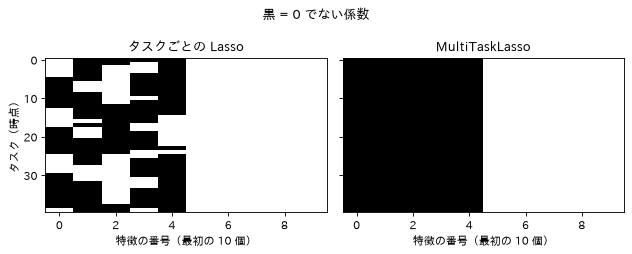

,特徴0,特徴1,特徴2,特徴3,特徴4,特徴5
40 タスク中で選ばれた回数,,,,,,
タスクごとの Lasso,24,29,17,28,31,0
MultiTaskLasso,40,40,40,40,40,0


In [19]:
rng_mt = np.random.RandomState(42)
n_samples, n_features, n_tasks, n_relevant = 100, 30, 40, 5
true_coef = np.zeros((n_tasks, n_features))
times = np.linspace(0, 2 * np.pi, n_tasks)
for k in range(n_relevant):
    true_coef[:, k] = np.sin((1.0 + rng_mt.randn(1)) * times + 3 * rng_mt.randn(1))
X_mt = rng_mt.randn(n_samples, n_features)
Y_mt = X_mt @ true_coef.T + rng_mt.randn(n_samples, n_tasks)

coef_lasso = np.array([lm.Lasso(alpha=0.5).fit(X_mt, y).coef_ for y in Y_mt.T])   # タスクごとに Lasso
coef_mtl = lm.MultiTaskLasso(alpha=1.0).fit(X_mt, Y_mt).coef_

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), sharey=True)
for ax, c, title in [(axes[0], coef_lasso, "タスクごとの Lasso"), (axes[1], coef_mtl, "MultiTaskLasso")]:
    ax.imshow(c[:, :10] != 0, aspect="auto", cmap="Greys", interpolation="nearest")
    ax.set_title(title); ax.set_xlabel("特徴の番号（最初の 10 個）"); ax.grid(False)
axes[0].set_ylabel("タスク（時点）")
fig.suptitle("黒 = 0 でない係数"); plt.tight_layout(); plt.show()

pd.DataFrame({"タスクごとの Lasso": (coef_lasso != 0).sum(axis=0)[:6],
              "MultiTaskLasso": (coef_mtl != 0).sum(axis=0)[:6]},
             index=[f"特徴{i}" for i in range(6)]).T.rename_axis("40 タスク中で選ばれた回数")

👀 左の図（タスクごとの Lasso）は黒が**まだら**です。係数が 0 付近を通る時点では、その特徴が外されてしまいます。右の図（MultiTaskLasso）は、選ばれた 5 つの特徴が**全 40 タスクで縦にそろって**います。ガイドの図と同じ結果です。

📖 実装は `Lasso` と同じく座標降下法です。

> ⚠️ **つまずきポイント**: 信号が強くノイズが小さいデータでは、タスクごとの Lasso でも同じ特徴が選ばれ、両者の差は見えにくくなります（このノートの旧版ではそうなりました）。差がはっきり出るのは、係数が 0 付近を通るタスクがあるときです。

---
## 5. Elastic-Net（1.1.5）と Multi-task Elastic-Net（1.1.6）

**ねらい**: Ridge と Lasso の「いいとこ取り」がどういう場面で効くかを知る。

### 📖 ガイドの解説

`ElasticNet` は、係数に **L1 と L2 の両方**のペナルティをかける線形回帰です。Lasso のように少数の係数だけを 0 でなくしながら、Ridge の安定性も保てます。L1 と L2 の混ぜ具合は `l1_ratio`（式では $\rho$）で決めます。

$$\min_{w} \frac{1}{2 n_\text{samples}} \| X w - y \|_2^2 + \alpha \rho \| w \|_1 + \frac{\alpha (1 - \rho)}{2} \| w \|_2^2$$

- `l1_ratio = 1` なら Lasso、`l1_ratio = 0` なら Ridge と同じです。
- **互いに相関する特徴が複数あるとき、Lasso はそのうち 1 つをランダムに選びがちですが、Elastic-Net は両方を選びやすい**性質があります。
- Ridge の性質を受け継ぐので、特徴の回転に対しても安定しています。
- `ElasticNetCV` を使うと、`alpha` と `l1_ratio` を交差検証で選べます。

### 🔢 数式を読む

| 記号 | 意味 |
|---|---|
| $\alpha$ | 罰全体の強さ（`alpha`） |
| $\rho$ | 罰のうち L1 に回す割合（`l1_ratio`、0〜1） |
| $\alpha \rho \lVert  w \rVert _1$ | Lasso と同じ絶対値の罰。係数を 0 にする力 |
| $\frac{\alpha (1 - \rho)}{2} \lVert  w \rVert _2^2$ | Ridge と同じ二乗の罰。似た特徴の係数をそろえる力 |

**日本語で読むと**: 罰の総額を $\alpha$ で決め、そのうち割合 $\rho$ を「0 にする罰（L1）」、残りを「なめらかに縮める罰（L2）」に配分する。

> 📚 **用語**: **特徴の回転に対する安定性** — 特徴を回転させた（互いに混ぜ合わせた）ときに、結果が大きく変わらないこと。L2 ノルムは回転しても長さが変わらないので Ridge はこの性質を持ち、L1 ノルムは座標軸に依存するので Lasso は持たない。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 Lasso の弱点は、(1) 似た特徴のグループから 1 つだけを気まぐれに選ぶこと、(2) 特徴数がサンプル数より多いとき、選べる特徴の数がサンプル数までに限られること、の 2 つです。Elastic-Net は L2 の罰を足すことでこれらを和らげます。
- 🏭 **遺伝子発現データ**（同じ働きをする遺伝子のグループをまとめて選びたい）、**マーケティング**（互いに相関する広告チャネルの効果をまとめて評価したい）など。
- 🕰️ **2005 年**に **ゾウ（Hui Zou）とヘイスティ（Trevor Hastie）**が、論文 *Regularization and variable selection via the elastic net*（JRSS B）で提案しました。「伸縮する網（elastic net）が、似た魚（相関する特徴）をまとめて捕まえる」というたとえが名前の由来とされています。

### 🧪 やってみよう: そっくりな 2 つの特徴があるとき

特徴 0 と 1 がほぼ同じ値で、特徴 2 は無関係なデータを、乱数の種を変えて 5 通り作ります。「Lasso はランダムに 1 つを選ぶ」が本当か確かめます。

In [20]:
rows = []
for seed in range(5):
    r = np.random.RandomState(seed)
    z_en = r.randn(200)
    X_en = np.c_[z_en + 0.01 * r.randn(200),   # 特徴 0 と 1 はほぼ同じ
                 z_en + 0.01 * r.randn(200),
                 r.randn(200)]                   # 特徴 2 は無関係
    y_en = 2 * z_en + 0.1 * r.randn(200)
    las = lm.Lasso(alpha=0.1, max_iter=100_000).fit(X_en, y_en)   # 収束するまで回す（理由は下で）
    en = lm.ElasticNet(alpha=0.1, l1_ratio=0.3).fit(X_en, y_en)
    rows.append({"データ": f"種 {seed}",
                 "Lasso 特徴0": las.coef_[0], "Lasso 特徴1": las.coef_[1], "Lasso 反復回数": las.n_iter_,
                 "EN 特徴0": en.coef_[0], "EN 特徴1": en.coef_[1], "EN 特徴2": en.coef_[2]})
pd.DataFrame(rows).set_index("データ")

,Lasso 特徴0,Lasso 特徴1,Lasso 反復回数,EN 特徴0,EN 特徴1,EN 特徴2
データ,,,,,,
種 0,1.9008,0.0000,2,0.9543,0.9509,0.0
種 1,1.5860,0.2932,1529,0.9424,0.9415,-0.0
種 2,0.6993,1.2190,5734,0.9598,0.9612,0.0
種 3,0.1938,1.7092,5333,0.9520,0.9554,0.0
種 4,0.9192,0.9664,5188,0.9448,0.9450,-0.0


👀 どちらのモデルも、無関係な特徴 2 はきちんと 0 にしています。違いは、そっくりな特徴 0 と 1 の扱いです。

- **Lasso** は、データによって「特徴 0 に全部寄せる」「特徴 1 に大きく寄せる」「ほぼ半々」とバラバラです。どちらを選ぶかは、ノイズのわずかな違いで決まってしまいます。ガイドの言う「**ランダムに 1 つを選びがち**」とはこのことです。
- **Elastic-Net** は、どのデータでも**ほぼ半々**に分けています。L2 の部分が「似た特徴には似た係数を」という方向に働くためです。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: そっくりな特徴があると、Lasso の座標降下法は**収束がとても遅く**なります。表の反復回数は数千回に達しており、既定の `max_iter=1000` のままだと途中で止まって `ConvergenceWarning` が出ます（試したところ、種 2〜4 で警告が出ました）。警告を無視すると、収束途中の係数を「答え」として読むことになります。

どちらが良いかは目的次第です。「同じ意味の特徴はまとめて残したい」（例: 同じ遺伝子グループの複数の測定値）なら Elastic-Net、「1 つに絞って説明を簡単にしたい」なら Lasso が向いています。どちらの場合も、無関係な特徴 2 はきちんと 0 になっています。

### 1.1.6 Multi-task Elastic-Net

📖 `MultiTaskElasticNet` は、Multi-task Lasso の Elastic-Net 版です。混合ノルム $\ell_1 \ell_2$ と L2 ノルムの両方で正則化し、「全タスクで同じ特徴を選ぶ」制約を保ちます。`MultiTaskElasticNetCV` で `alpha` と `l1_ratio` を交差検証で選べます。

$$\min_{W} \frac{1}{2 n_\text{samples}} \| X W - Y \|_\text{Fro}^2 + \alpha \rho \| W \|_{21} + \frac{\alpha (1 - \rho)}{2} \| W \|_\text{Fro}^2$$

In [21]:
coef_mten = lm.MultiTaskElasticNet(alpha=1.0, l1_ratio=0.7).fit(X_mt, Y_mt).coef_
used = (coef_mten != 0)
print("選ばれた特徴:", np.flatnonzero(used.any(axis=0)))
print("選ばれた特徴は全タスクでそろっているか:", (used.all(axis=0) | ~used.any(axis=0)).all())

選ばれた特徴: [ 0  1  2  3  4  5  8 10 12 19 25]
選ばれた特徴は全タスクでそろっているか: True


👀 Multi-task Lasso と同じく、特徴単位でそろった選び方になりました。ただし、本当に効くのは特徴 0〜4 だけなのに、無関係な特徴もいくつか選ばれています。L2 の部分がある分、Multi-task Lasso よりスパースさが弱まるためです（この `alpha` と `l1_ratio` の場合）。

---
## 6. まとめ

### 手法の比較表

| 手法 | ペナルティ | 係数の縮み方 | 0 にするか | 向いている場面 |
|---|---|---|---|---|
| `LinearRegression` | なし | 縮まない | しない | 特徴が少なく、互いに独立 |
| `Ridge` | L2（二乗和） | 全体をなめらかに縮める | しない | 相関の強い特徴が多い。予測を安定させたい |
| `Lasso` | L1（絶対値の和） | 一定量ずつ縮め、0 で止める | **する** | 効く特徴は少数だと思われる。特徴選択したい |
| `ElasticNet` | L1 + L2 | 両方の中間 | する | 相関する特徴をまとめて残しつつ選択したい |
| `MultiTask*` | 混合ノルム | 特徴単位でそろえる | 特徴ごと丸ごと | 複数の目的変数で同じ特徴を使いたい |
| `*CV` 付き | 上と同じ | — | — | `alpha` を交差検証で自動選択したい |

### 覚えておきたい 3 つのこと

1. **正則化は「係数への税金」**。`alpha` を大きくするほど係数は小さくなり、極端な値が出なくなる。
2. **Ridge は縮める、Lasso は 0 にする**。違いはペナルティが二乗か絶対値かだけで、ソフトしきい値の図がすべてを表している。
3. **係数の解釈は、特徴どうしの相関に弱い**。予測がうまくいっていても、係数の大小を「重要度」として読むときは注意する。

### 🧩 ドメインモデルの視点

- `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet` は、どれも `fit(X, y)` して `coef_` / `intercept_` を持つという**同じ契約**に従っています。だから比較実験のコードで、モデル名を差し替えるだけで済みました。
- `RidgeCV` や `LassoCV` は「ハイパーパラメータ探索を内蔵した Estimator」です。探索の一般形は 3.2 節の `GridSearchCV`（Estimator を包むメタ推定器）で学びます。
- ただし契約の細部はそろっていません（`RidgeClassifier.coef_` の形など）。「同じインターフェースでも、返す値の形まで同じとは限らない」ことは、型のある言語で設計するときにも注意したい点です。

### ✅ 確認クイズ

**Q1.** `alpha` を大きくすると、Ridge の係数はどうなりますか。0 になりますか。

<details><summary>答え</summary>

全体がなめらかに 0 へ近づきますが、ちょうど 0 にはなりません（正則化パスの図）。
</details>

**Q2.** 2 つの特徴がほぼ同じ値のとき、OLS・Ridge・Lasso・Elastic-Net の係数はそれぞれどうなりやすいですか。

<details><summary>答え</summary>

OLS はデータの小さな揺れで大きくぶれる。Ridge と Elastic-Net は 2 つに分け合う。Lasso はどちらか 1 つに寄せて、もう片方を 0 にする。
</details>

**Q3.** `LassoLarsIC` の BIC が AIC より少ない特徴を選びやすいのはなぜですか。

<details><summary>答え</summary>

パラメータ 1 個あたりの罰が、AIC は 2、BIC は $\log N$ だからです。サンプル数 $N$ が 8 以上なら $\log N > 2$ となり、BIC の罰のほうが重くなります。
</details>

**Q4.** 40 店舗の売上を予測するとき、「どの店舗でも同じ特徴を使いたい」なら、どのクラスを使いますか。

<details><summary>答え</summary>

`MultiTaskLasso`（または `MultiTaskElasticNet`）。`y` を `(n_samples, 40)` の 2 次元配列にして渡します。
</details>

---
**次のノート**: [1.1 線形モデル（2/4）特徴選択とベイズ回帰](./01_linear_models_2_selection_bayes.ipynb) — LARS, OMP, Bayesian Ridge, ARD